## US-Accidents' Dataset Analysis - Rush Hour VS Severity
**Perspective:** Analysis of the relationship between rush hours and accident severity  
**Analyst:** Emma Lehtoranta  

This study examines how rush hour traffic affects both the frequency and severity of road accidents in the United States. The goal is to determine whether peak traffic periods lead to more severe accidents or primarily increase accident occurrence.
By analysing time-based patterns in accident data, this analysis aims to provide insights into how traffic conditions influence road safety.


In [2]:
from pymongo import MongoClient
import pandas as pd
import time

client = MongoClient("mongodb://localhost:27017/")
db = client['US-Accidents']
collection = db['accidents']

### MongoDB
- Within the project, MongoDB is used for storing and retrieving the accident data

In [3]:
# Loads the data onto MongoDB OR indicates whether it's already downloaded
count = collection.count_documents({})
print(f"Documents within MongoDB: {count}")

if count == 0:
    chunk_size = 10000
    total = 0
    for chunk in pd.read_csv("US_Accidents_March23.csv", chunksize=chunk_size):
        records = chunk.to_dict("records")
        collection.insert_many(records)
        total += len(records)
        print(f"Downloaded: {total} rows...")
    print(f"Finished! Total amount of documents: {total}")
else:
    print("Data's already downloaded, so skipping the download!")

Documents within MongoDB: 7728394
Data's already downloaded, so skipping the download!


### Checking the columns

In [4]:
doc = collection.find_one()
keys = list(doc.keys()) # Gives all the column names from the dataset

chunk_size = 23
columns = [keys[i:i+chunk_size] for i in range(0, len(keys), chunk_size)]

max_len = max(len(col) for col in columns)

for row in range(max_len):
    line = ""
    for col_idx, col in enumerate(columns):
        if row < len(col):
            num = col_idx * chunk_size + row
            line += f"{num:<4}{col[row]:<30}"
    print(line)

0   _id                           23  Humidity(%)                   46  Astronomical_Twilight         
1   ID                            24  Pressure(in)                  
2   Source                        25  Visibility(mi)                
3   Severity                      26  Wind_Direction                
4   Start_Time                    27  Wind_Speed(mph)               
5   End_Time                      28  Precipitation(in)             
6   Start_Lat                     29  Weather_Condition             
7   Start_Lng                     30  Amenity                       
8   End_Lat                       31  Bump                          
9   End_Lng                       32  Crossing                      
10  Distance(mi)                  33  Give_Way                      
11  Description                   34  Junction                      
12  Street                        35  No_Exit                       
13  City                          36  Railway                       


### Optimisation test: comparing embedded and referenced MongoDB models
- Indexing was applied to improve query performance.

In [5]:
# Benchmark embedded model
collection.create_index("Start_Time")

start = time.time()
list(collection.find({"Start_Time": {"$exists": True}}).limit(1000))
embedded_time = time.time() - start
print(f"Embedded query: {embedded_time:.4f}s")

# Create sample dataset
sample = list(collection.find(
    {},
    {
        "Severity": 1,
        "Start_Time": 1
    }
).limit(50000))

# Referenced model
accidents_ref = db["accidents_referenced"]
time_ref = db["time_referenced"]

accidents_ref.drop()
time_ref.drop()

for doc in sample:
    time_id = doc["_id"]

    time_ref.insert_one({
        "time_id": time_id,
        "Start_Time": doc.get("Start_Time")
    })

    accidents_ref.insert_one({
        "Severity": doc.get("Severity"),
        "time_id": time_id
    })

# Index referenced collections
accidents_ref.create_index("time_id")
time_ref.create_index("time_id")

# Benchmark referenced model
start = time.time()
accidents = list(accidents_ref.find().limit(1000))

for acc in accidents:
    time_ref.find_one({"time_id": acc["time_id"]})

referenced_time = time.time() - start

print(f"Referenced query: {referenced_time:.4f}s")
print(f"\nEmbedded model was {referenced_time/embedded_time:.1f}x faster")

Embedded query: 0.0100s
Referenced query: 0.2343s

Embedded model was 23.4x faster


### Spark Session startup

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import count, avg, round

spark = SparkSession.builder \
    .appName("RushHourAndSeverity_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "20g") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .config("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1:27017/US-Accidents.accidents") \
    .getOrCreate()

### Spark Session startup

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, when, count, avg, round


spark = SparkSession.builder \
    .appName("RushHourAndSeverity_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "16g") \
    .getOrCreate()

### Loading data from MongoDB

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, when, count, avg, round


spark = SparkSession.builder \
    .appName("RushHourAndSeverity_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "16g") \
    .getOrCreate()

### Clean the Data

In [11]:
print("Documents:", collection.count_documents({}))

cursor = collection.find(
    {},
    {
        "Severity": 1,
        "Start_Time": 1,
        "_id": 0
    }
)#.limit(500000)  


pandas_df = pd.DataFrame(list(cursor))

print("Rows fetched:", len(pandas_df))
print(pandas_df.head(3))
print(pandas_df.dtypes)

Documents: 7728394
Rows fetched: 7728394
   Severity           Start_Time
0         3  2016-02-08 05:46:00
1         2  2016-02-08 06:07:59
2         2  2016-02-08 06:49:27
Severity      int64
Start_Time      str
dtype: object


### Convert to Spark

In [12]:
df = spark.createDataFrame(pandas_df)

# Convert Pandas → Spark
df = spark.createDataFrame(pandas_df)

# Cache for performance
df = df.cache()
row_count = df.count()
print("Cache loaded!")
print("Rows in DataFrame:", row_count)

# Extract hour
df = df.withColumn("hour", hour(col("Start_Time")))

# Create Traffic_Period categories
df = df.withColumn(
    "Traffic_Period",
    when((col("hour") >= 6) & (col("hour") < 10), "Morning Rush")
    .when((col("hour") >= 15) & (col("hour") < 19), "Afternoon Rush")
    .when((col("hour") >= 10) & (col("hour") < 15), "Midday")
    .otherwise("Late evening/night")  # 19:00–06:00
)

KeyboardInterrupt: 

### Analyse the rush hour effect

In [ ]:
print("Accidents by traffic period category:")
df.groupBy("Traffic_Period").agg(
    count("*").alias("accident_count"),
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("accident_count", ascending=False).show()

print("Accidents by hour:")
df.groupBy("hour").agg(
    count("*").alias("accident_count"),
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("hour").show()

Accidents by traffic period category:
+------------------+--------------+------------+
|    Traffic_Period|accident_count|avg_severity|
+------------------+--------------+------------+
|    Afternoon Rush|       1890813|        2.23|
|      Morning Rush|       1797678|        2.21|
|            Midday|       1699802|        2.23|
|Late evening/night|       1596935|        2.25|
+------------------+--------------+------------+

Accidents by hour:
+----+--------------+------------+
|hour|accident_count|avg_severity|
+----+--------------+------------+
|   0|         98452|        2.24|
|   1|         85743|         2.2|
|   2|         82524|        2.22|
|   3|         74099|        2.25|
|   4|        149077|        2.24|
|   5|        209579|        2.23|
|   6|        375179|        2.22|
|   7|        546789|         2.2|
|   8|        541643|         2.2|
|   9|        334067|        2.24|
|  10|        313625|        2.24|
|  11|        322215|        2.23|
|  12|        316904|    

### Testing Spark SQL's functionality

In [ ]:
df.createOrReplaceTempView("accidents")

spark.sql("""
SELECT hour, COUNT(*) AS accident_count, AVG(Severity) AS avg_severity
FROM accidents
GROUP BY hour
ORDER BY hour
""").show(24)

+----+--------------+------------------+
|hour|accident_count|      avg_severity|
+----+--------------+------------------+
|   0|         98452|2.2380855645390647|
|   1|         85743| 2.202570472225138|
|   2|         82524|2.2212689641801173|
|   3|         74099|2.2477496322487482|
|   4|        149077|2.2446722163714052|
|   5|        209579|2.2328763855157243|
|   6|        375179| 2.221776805204982|
|   7|        546789| 2.200719107370485|
|   8|        541643| 2.200499221812153|
|   9|        334067|2.2400446616995993|
|  10|        313625|2.2352012754085293|
|  11|        322215|2.2302530918796455|
|  12|        316904| 2.235714916820236|
|  13|        352361|2.2275932921066746|
|  14|        394697|2.2218942631942986|
|  15|        463389| 2.223544365533062|
|  16|        520177| 2.225461717838351|
|  17|        516626| 2.230133597612199|
|  18|        390621| 2.246673885940592|
|  19|        267045| 2.255458817802243|
|  20|        201883| 2.267843255747141|
|  21|        16

In [ ]:
spark.sql("""
SELECT 
    Traffic_Period,
    COUNT(*) AS accident_count,
    ROUND(AVG(Severity), 2) AS avg_severity
FROM accidents
GROUP BY Traffic_Period
""").show()

+------------------+--------------+------------+
|    Traffic_Period|accident_count|avg_severity|
+------------------+--------------+------------+
|    Afternoon Rush|       1890813|        2.23|
|            Midday|       1699802|        2.23|
|Late evening/night|       1596935|        2.25|
|      Morning Rush|       1797678|        2.21|
+------------------+--------------+------------+



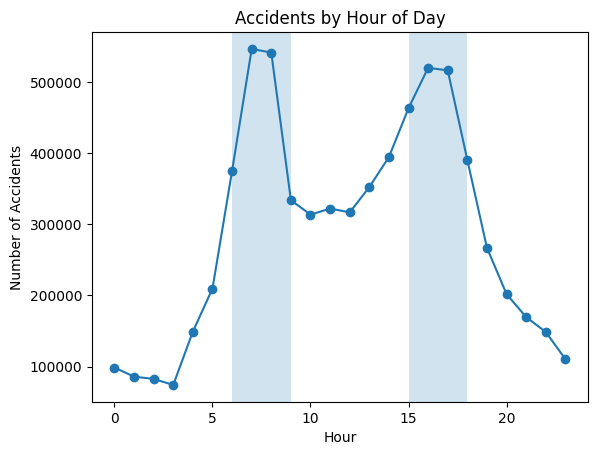

In [ ]:
import matplotlib.pyplot as plt

hourly_pd = df.groupBy("hour").agg(
    count("*").alias("accident_count")
).orderBy("hour").toPandas()

plt.figure()
plt.plot(hourly_pd["hour"], hourly_pd["accident_count"], marker="o")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.axvspan(6, 9, alpha=0.2) 
plt.axvspan(15, 18, alpha=0.2)
plt.show()

### What this graph tells us?
- There are clear peak hours during the day for the amount of accidents happening 
- The peaks do seem to be aligned with rush-hours

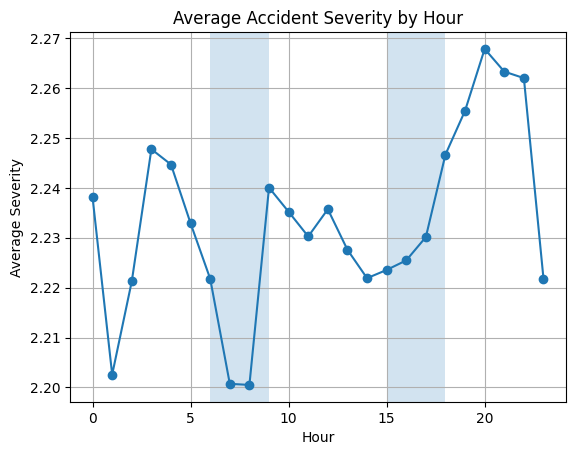

In [ ]:
hourly_pd = df.groupBy("hour").agg(
    avg("Severity").alias("avg_severity")
).orderBy("hour").toPandas()

plt.figure()
plt.plot(hourly_pd["hour"], hourly_pd["avg_severity"], marker="o")
plt.title("Average Accident Severity by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Severity")
plt.axvspan(6, 9, alpha=0.2) 
plt.axvspan(15, 18, alpha=0.2)
plt.grid()
plt.show()

### What this graph tells us?
- Severity doesn't seem to align nearly as strongly with rush-hours
- Severity seems to be more correlated with late hours than rush-hours though there is a smaller peak at 15 o'clock
- The most significant peak is most severe accidents seems to be after midnight around 1 and 2 am, which could mean several things really:
    - Speeding is more rampant during the night as there's usually less traffic
    - Drivers could be more tired and therefore cognitive skills are more limited
    - Drivers could be under the influence of various substances during the night more often than daytime